# Project 3 Assignment

## Assignment Overview & Instructions

The objective of project 3 is to perform keyword network analysis and word frequency
analysis.  
Please complete the following 7 tasks in this assessment, using the instructions indicated below.   

**Note:** You may create your own custom functions if necessary to complete the tasks.

### Task 1: Import the Dataset for use in your Notebook.   

You can find the source dataset [here](https://drive.google.com/file/d/1YJe45YXo0xSkFClGPBhKYLzupFEyGadK/view?usp=sharing)

In [10]:
## YOUR CODE HERE

import pandas as pd

df = pd.read_csv('data/keywords_data.csv')

df.head()

,Title,Keyword 1,Keyword 2,Keyword 3,Keyword 4,Keyword 5,Keyword 6,Keyword 7,Keyword 8,Keyword 9,Keyword 10,Keyword 11,Keyword 12
0,Feb/03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Meta-Analyses of Financial Performance and Equ...,EQUITY,ORGANIZATIONAL sociology,PERFORMANCE,META-analysis,PSYCHOMETRICS,ORGANIZATIONAL research,FINANCIAL performance,AGENCY theory,ORGANIZATIONAL effectiveness,ORGANIZATIONAL behavior,CORPORATE governance,NaN
3,"Home Country Environments, Corporate Diversifi...",DIVERSIFICATION in industry,BUSINESS planning,PERFORMANCE standards,EMPLOYEES -- Rating of,CORPORATE culture,STRATEGIC planning,ORGANIZATIONAL effectiveness,MANAGEMENT science,MANAGEMENT research,PRODUCT management,NaN,NaN
4,Safeguarding Investments in Asymmetric Interor...,INTERORGANIZATIONAL relations,INTERGROUP relations,BUSINESS communication,INVESTMENTS,SUPPLY chains,KNOWLEDGE management,INTERORGANIZATIONAL networks,CORPORATE governance,GROUP decision making,INTELLECTUAL capital,NaN,NaN


### **Task 2:**  Write a Python code to extract keyword data from the above file. 
Write a Python code to extract keyword data from the above file and convert it to a weighted adjacency matrix. See the figure below to understand the process

![Task Two - Adjacency matrix](Task%202%20-%20Figure%201.png)

In [11]:
## YOUR CODE HERE
import nltk
import string
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from nltk.corpus import stopwords
import re
nltk.download('punkt_tab', quiet ='True')
from nltk.tokenize import word_tokenize
nltk.download('stopwords', quiet ='True')

# Extract and preprocess keywords
keyword_cols = [f'Keyword {i}' for i in range (1, 13)]

keyword_df = df[keyword_cols].dropna(how='all')

all_keywords = []
for index, row in keyword_df.iterrows():
    keywords = row.dropna().astype(str).str.lower().str.strip().tolist()
    if keywords:
        all_keywords.append(keywords)

#Generate co-occurrence pairs (bidirectional)
# ('a', 'cat') and ('cat', 'a') are treated as separate occurrences,
# so the final weight = 2 × the number of articles they co-occur in
co_occurrence_pairs = list()
for tokens in all_keywords:
    filtered_tokens = list(set(tokens))   # No duplicate but not sorting
    co_occurrence_pairs += [
        (filtered_tokens[i], filtered_tokens[j])
        for i in range(len(filtered_tokens))
        for j in range(len(filtered_tokens))  # j iterates over ALL tokens, including i
        if i != j                             # exclude self-pairs (a, a)
    ]

# weight pairs using frequency distribution
weighted_co_occurrences = nltk.FreqDist(co_occurrence_pairs)
print(f'weighted_co_occurrences: {weighted_co_occurrences.most_common(10)}...')

# Fill adjacency matrix — now each cell is already bidirectional so no need to mirror
unique_keywords = sorted(set(word for pair in weighted_co_occurrences.keys() for word in pair))
print(f'Unique Keywords found: {len(unique_keywords)}')

adj_df = pd.DataFrame(0, index = unique_keywords, columns = unique_keywords)

for (kw1, kw2), weight in weighted_co_occurrences.items():
    adj_df.at[kw1,kw2] = weight
    adj_df.at[kw2,kw1] = weight


print('\nAdjacency Matrix shape' , adj_df.shape)

# Verify symmetry
is_symmetric = adj_df.equals(adj_df.T)
print(f"Is matrix symmetric? {is_symmetric}")

adj_df.head()

weighted_co_occurrences: [(('organizational behavior', 'organizational effectiveness'), 11), (('organizational effectiveness', 'organizational behavior'), 11), (('organizational structure', 'organizational behavior'), 9), (('organizational behavior', 'organizational structure'), 9), (('personnel management', 'organizational behavior'), 8), (('organizational behavior', 'personnel management'), 8), (('organizational behavior', 'management science'), 7), (('management science', 'organizational behavior'), 7), (('organizational sociology', 'organizational behavior'), 6), (('corporate governance', 'organizational behavior'), 6)]...
Unique Keywords found: 248

Adjacency Matrix shape (248, 248)
Is matrix symmetric? True


,agency theory,aggression (psychology),ambivalence,anger in the workplace,behavioral research,boards of directors,break-even analysis,burnout (psychology),business communication,business enterprises,...,violence in the workplace,wage payment systems,wages,women -- employment,women employees,work & family,work attitudes,work environment,work environment -- psychological aspects,workflow
agency theory,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
aggression (psychology),0,0,0,1,0,0,0,0,0,0,...,1,0,0,0,0,0,1,2,0,0
ambivalence,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
anger in the workplace,0,1,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,1,0,0
behavioral research,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Task 3:**  Read the adjacency matrix and convert it into a weighted network


Network summary:
  Nodes (keywords) : 248
  Edges (pairs)    : 2141
  Density          : 0.0699

Top 15 keywords by weighted degree:
                                Weighted_Degree  Betweenness  PageRank
organizational behavior                     265     0.208043  0.046239
organizational effectiveness                144     0.105075  0.025300
management science                          136     0.086903  0.024188
personnel management                        126     0.072894  0.022256
decision making                             112     0.092395  0.020645
organizational structure                    107     0.039925  0.018762
organizational sociology                     96     0.026746  0.016543
corporate governance                         85     0.024082  0.014946
industrial management                        84     0.027568  0.014835
strategic planning                           80     0.047741  0.014654
teams in the workplace                       78     0.017960  0.013537
organizational

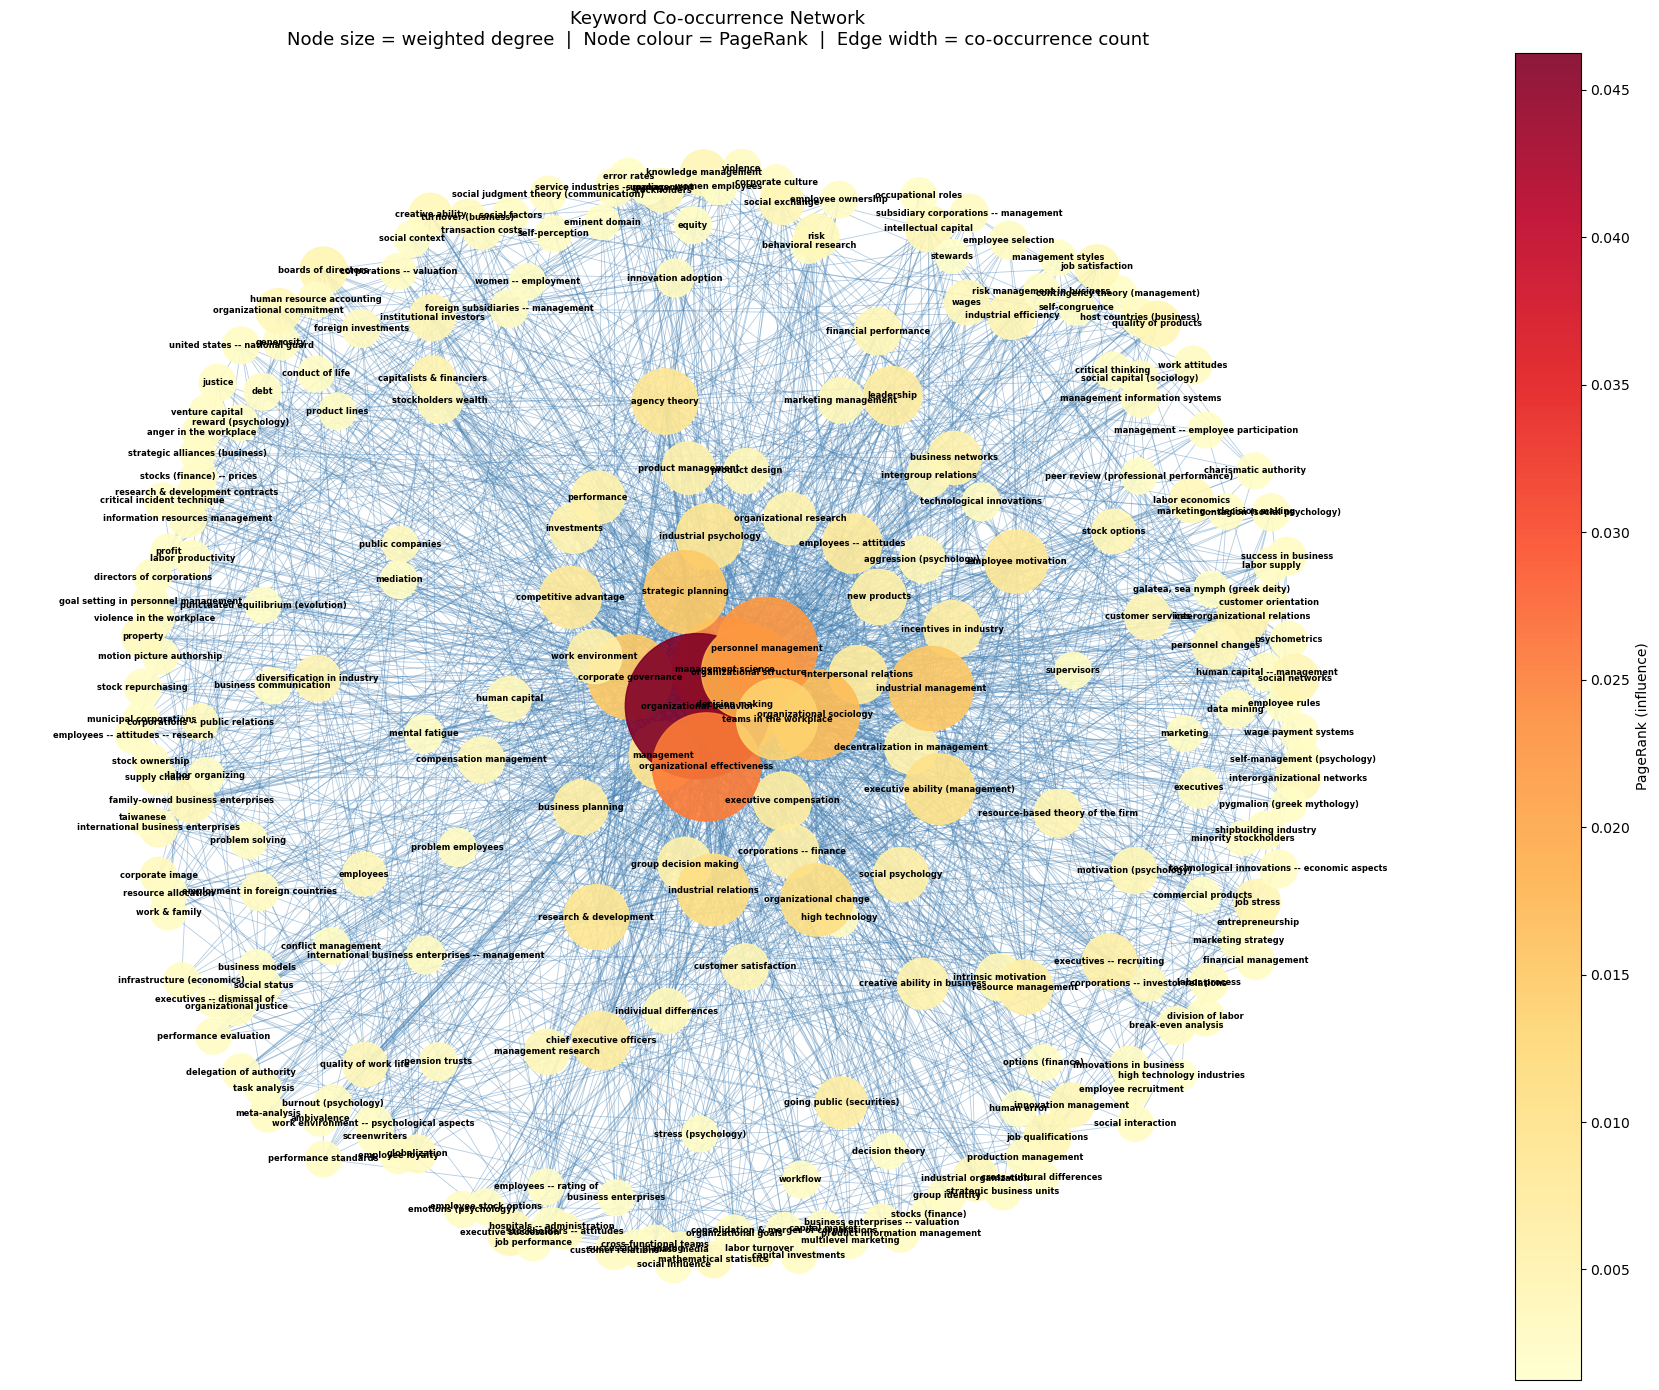

In [12]:
## YOUR CODE HERE
from itertools import combinations
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Build NetworkX graph from adjacency matrix 
G = nx.from_pandas_adjacency(adj_df)

# Remove self-loops (diagonal) and zero-weight edges
G.remove_edges_from(nx.selfloop_edges(G))
edges_to_remove = [(u, v) for u, v, w in G.edges(data="weight") if w == 0]
G.remove_edges_from(edges_to_remove)

print(f"\nNetwork summary:")
print(f"  Nodes (keywords) : {G.number_of_nodes()}")
print(f"  Edges (pairs)    : {G.number_of_edges()}")
print(f"  Density          : {nx.density(G):.4f}")

# Compute node-level metrics 
degree      = dict(G.degree(weight="weight"))       # weighted degree (strength)
betweenness = nx.betweenness_centrality(G, weight="weight")
pagerank    = nx.pagerank(G, weight="weight")

metrics_df = pd.DataFrame({
    "Weighted_Degree": degree,
    "Betweenness"    : betweenness,
    "PageRank"       : pagerank,
}).sort_values("Weighted_Degree", ascending=False)

print("\nTop 15 keywords by weighted degree:")
print(metrics_df.head(15).to_string())


# Visualise the network 
fig, ax = plt.subplots(figsize=(18, 14))

# Layout
pos = nx.spring_layout(G, seed=42, k=1.5)

# Visual scaling
weights      = [G[u][v]["weight"] for u, v in G.edges()]
node_sizes   = [300 + degree[n] * 40 for n in G.nodes()]
node_colors  = [pagerank[n] for n in G.nodes()]

# Draw
nx.draw_networkx_edges(
    G, pos, ax=ax,
    width=[w * 0.6 for w in weights],
    alpha=0.4,
    edge_color="steelblue"
)
nodes = nx.draw_networkx_nodes(
    G, pos, ax=ax,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=cm.YlOrRd,
    alpha=0.9
)
nx.draw_networkx_labels(
    G, pos, ax=ax,
    font_size=6,
    font_weight="bold"
)

# Colorbar
plt.colorbar(nodes, ax=ax, label="PageRank (influence)")

ax.set_title(
    "Keyword Co-occurrence Network\n"
    "Node size = weighted degree  |  Node colour = PageRank  |  Edge width = co-occurrence count",
    fontsize=13
)
ax.axis("off")
plt.tight_layout()

plt.show()

### **Task 4:**  Compute node degree and strength

In [13]:
## YOUR CODE HERE
# Compute node degree and strength
# Degree   = number of distinct keywords a node is connected to (unweighted)
# Strength = sum of edge weights for a node (weighted degree)
degree   = dict(G.degree())                   # unweighted: counts edges
strength = dict(G.degree(weight="weight"))    # weighted:   sums co-occurrence counts

metrics_df = pd.DataFrame({
    "Degree"  : degree,
    "Strength": strength,
}).sort_values("Strength", ascending=False)

metrics_df.index.name = "Keywords"

metrics_df

,Degree,Strength
Keywords,,
organizational behavior,166,265
organizational effectiveness,104,144
management science,102,136
personnel management,93,126
decision making,90,112
...,...,...
minority stockholders,8,8
stewards,7,7
cross-cultural differences,7,7


### **Task 5:**  Show the top 10 nodes by degree and top 10 nodes by strength

In [14]:
## YOUR CODE HERE
top10_degree   = metrics_df.nlargest(10, "Degree")[["Degree"]]
top10_strength = metrics_df.nlargest(10, "Strength")[["Strength"]]

# Side-by-side display
comparison = pd.concat(
    [top10_degree.reset_index(), top10_strength.reset_index()],
    axis=1
)
comparison.columns   = ["Keyword (Degree)", "Degree", "Keyword (Strength)", "Strength"]
comparison.index     = range(1, 11)


print("\n" + "="*95)
print(f"{'':<6}{'Top 10 by Degree':<35}{'Degree':>6}  {'Top 10 by Strength':<35}{'Strength':>8}")
print("="*95)
for rank, row in comparison.iterrows():
    print(f"{rank:<6}{row['Keyword (Degree)']:<35}{int(row['Degree']):>6}  "
          f"{row['Keyword (Strength)']:<35}{int(row['Strength']):>8}")



      Top 10 by Degree                   Degree  Top 10 by Strength                 Strength
1     organizational behavior               166  organizational behavior                 265
2     organizational effectiveness          104  organizational effectiveness            144
3     management science                    102  management science                      136
4     personnel management                   93  personnel management                    126
5     decision making                        90  decision making                         112
6     organizational structure               74  organizational structure                107
7     organizational sociology               66  organizational sociology                 96
8     strategic planning                     66  corporate governance                     85
9     industrial management                  64  industrial management                    84
10    corporate governance                   62  strategic planning  

### **Task 6:** Show the top 10 node pairs by weight

In [16]:
## YOUR CODE HERE
# Extract all edges from the graph as (keyword A, keyword B, weight) tuples
# G.edges(data=True) returns each edge once along with its attribute dictionary
# d["weight"] retrieves the co-occurrence count stored on each edge
pairs = (
    pd.DataFrame(
        [(u, v, d["weight"]) for u, v, d in G.edges(data=True)],
        columns=["Keyword A", "Keyword B", "Weight"]
    )
    .sort_values("Weight", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
pairs.index = range(1, 11)


print("\n" + "="*85)
print(f"{'':<6}{'Keyword A':<35}{'Keyword B':<35}{'Weight':>5}")
print("="*85)
for rank, row in pairs.iterrows():
   print(f"{rank:<6}{row['Keyword A']:<35}{row['Keyword B']:<35}{int(row['Weight']):>5}")



      Keyword A                          Keyword B                          Weight
1     organizational behavior            organizational effectiveness          11
2     organizational behavior            organizational structure               9
3     organizational behavior            personnel management                   8
4     management science                 organizational behavior                7
5     organizational effectiveness       organizational structure               6
6     organizational behavior            organizational sociology               6
7     corporate governance               organizational behavior                6
8     decision making                    organizational behavior                6
9     organizational behavior            organizational change                  5
10    industrial relations               organizational behavior                5


### **Task 7:** Plot strength on y-axis and degree on x-axis

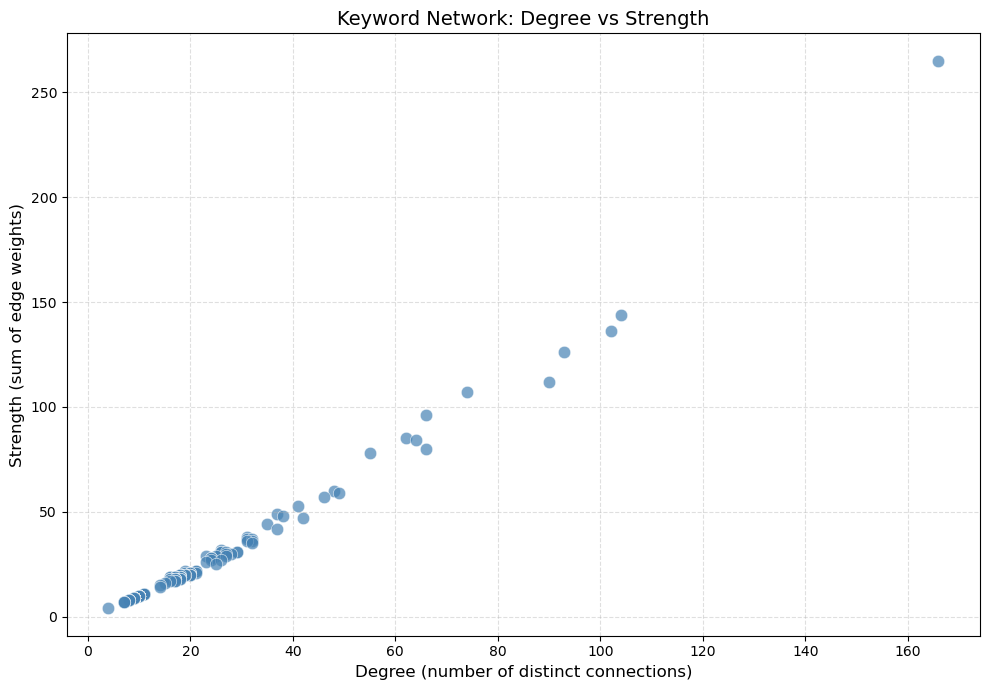

In [17]:
## YOUR CODE HERE
# Initialise a figure and axes with a defined size (width=10, height=7 inches)
fig, ax = plt.subplots(figsize=(10, 7))

# Extract degree and strength columns as x and y variables for readability
x = metrics_df["Degree"]
y = metrics_df["Strength"]

ax.scatter(x, y, color="steelblue", alpha=0.7, edgecolors="white", linewidths=0.5, s=80)

ax.set_xlabel("Degree (number of distinct connections)", fontsize=12)
ax.set_ylabel("Strength (sum of edge weights)", fontsize=12)
ax.set_title("Keyword Network: Degree vs Strength", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

## Submitting your Project

Once you've completed your project, it's time to submit your work for grading.   
This week, you will submit your code file `Project 3.ipynb` to the following Staff Graded Assignment for review.  

In order to submit your work, please follow the steps below:
1. Verify you've saved your work using the `Save` button within the Jupyter Notebook 
2. Download this notebook using the `File` -> `Download As` -> Choose the `Notebook (.ipynb)` format.
3. Access the following Step 2: Submit Project 3 item.
4. Complete all prompted fields, and upload your Jupyter Notebook file (Project 3.ipynb) in the indicated field.
5. Submit your notebook to "Step 2: Submit Project 3" by the deadline indicated within your course view for the Project 3 Assignment item.

Congratulations on completing the Project 3 Assignment!